Simple RNN – Predicting the Next Number

Import the required libraries

In [3]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

 Create the sequence

In [4]:
# Create sequence: 1 to 100
sequence = np.array([i for i in range(1, 101)])
print(sequence)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


Set the window size

In [5]:
# Define window size: 3 inputs → 1 output
window_size = 3

# X = inputs/questions
# y = correct answers
X = []
y = []

Create input-output pairs

In [8]:
# Create input-output pairs
for i in range(len(sequence) - window_size):
  X.append(sequence[i:i + window_size])
  y.append(sequence[i + window_size])

print( "First 5 input examples:")
print (X[:5 ])
print( "First 5 answers:")
print (y[:5 ])

First 5 input examples:
[array([1, 2, 3]), array([2, 3, 4]), array([3, 4, 5]), array([4, 5, 6]), array([5, 6, 7])]
First 5 answers:
[np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


5. Convert the data into NumPy arrays

In [9]:
X = np.array(X)
y = np.array(y)

print( "X shape:" , X.shape)
print( "y shape:" , y.shape)

X shape: (97, 3)
y shape: (97,)


6. Reshape X for the RNN

In [10]:
# Reshape X to: samples, timesteps, features
X = X.reshape((X.shape[0 ], X.shape[1], 1))
print( "New X shape:" , X.shape)

New X shape: (97, 3, 1)


7. Create the RNN model

In [11]:
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(window_size, 1)))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

8. Prepare the model for learning

In [12]:
model.compile(optimizer='adam', loss='mse')

9. Train the RNN

In [13]:
model.fit(X, y, epochs=500, verbose=2)
print("Training complete.")

Epoch 1/500
4/4 - 2s - 399ms/step - loss: 8415.3525
Epoch 2/500
4/4 - 0s - 13ms/step - loss: 6119.8574
Epoch 3/500
4/4 - 0s - 11ms/step - loss: 4282.9517
Epoch 4/500
4/4 - 0s - 12ms/step - loss: 2966.4207
Epoch 5/500
4/4 - 0s - 10ms/step - loss: 1901.5684
Epoch 6/500
4/4 - 0s - 11ms/step - loss: 1141.3398
Epoch 7/500
4/4 - 0s - 12ms/step - loss: 526.5527
Epoch 8/500
4/4 - 0s - 10ms/step - loss: 207.4352
Epoch 9/500
4/4 - 0s - 11ms/step - loss: 40.6286
Epoch 10/500
4/4 - 0s - 11ms/step - loss: 2.4053
Epoch 11/500
4/4 - 0s - 11ms/step - loss: 28.8748
Epoch 12/500
4/4 - 0s - 11ms/step - loss: 61.8313
Epoch 13/500
4/4 - 0s - 10ms/step - loss: 59.3787
Epoch 14/500
4/4 - 0s - 11ms/step - loss: 32.7493
Epoch 15/500
4/4 - 0s - 11ms/step - loss: 10.6455
Epoch 16/500
4/4 - 0s - 11ms/step - loss: 1.6712
Epoch 17/500
4/4 - 0s - 10ms/step - loss: 1.8503
Epoch 18/500
4/4 - 0s - 11ms/step - loss: 4.3323
Epoch 19/500
4/4 - 0s - 12ms/step - loss: 5.1748
Epoch 20/500
4/4 - 0s - 14ms/step - loss: 4.0571


10. Give a new input to the trained model

In [14]:
test_input = np.array([8 , 9, 10])
# RNN expects: samples, timesteps, features

test_input = test_input.reshape((1 , window_size, 1))
predicted = model.predict(test_input, verbose=0)
print( f"Predicted next number: { predicted[0][0] :.2f}")

Predicted next number: 10.53


11. Make predictions for all training examples

In [15]:
predictions = model.predict(X, verbose=0)

12. Plot the results

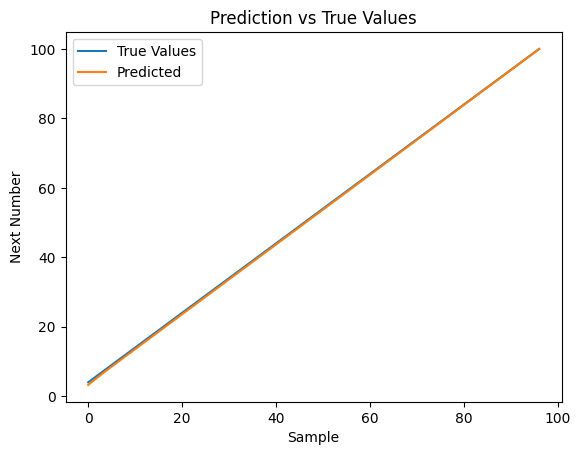

In [16]:
plt.plot(y, label= 'True Values')
plt.plot(predictions, label= 'Predicted')
plt.legend()
plt.title( "Prediction vs True Values")
plt.xlabel( "Sample")
plt.ylabel( "Next Number")
plt.show()